# History ablation — planning success

Planning success rate for IDR vs SIGReg across history lengths H in {1,2,3} on all four environments, mean +/- SEM over 5 seeds. Adapted from `planning_eval/plot_results.ipynb`. Run `aggregate_results.py` first.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def _repo_root(start):
    for c in [start.resolve(), *start.resolve().parents]:
        if (c / "plot_style.py").exists() and (c / "experiments").is_dir():
            return c
    return start.resolve()


REPO_ROOT = _repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from plot_style import FULL_WIDTH, apply_matplotlib_style, palette
    apply_matplotlib_style()
except Exception:
    FULL_WIDTH = 6.5
    palette = {"Dark Blue": "tab:blue", "Dark Red": "tab:red",
               "Light Blue": "#9ecae1", "Light Red": "#fcbba1",
               "Dark Grey": "0.3"}

EXP_DIR = REPO_ROOT / "experiments" / "history_ablation"
MANIFEST = EXP_DIR / "generated_configs" / "manifest.tsv"
ENV_ORDER = ["TwoRoom", "Reacher", "Push-T", "OGBench-Cube"]
METHOD_LABELS = {"idr": "IDR", "sigreg": "SIGReg"}
HISTORIES = [1, 2, 3]


In [2]:
CSV_PATH = EXP_DIR / "aggregated_results.csv"
df = pd.read_csv(CSV_PATH)
df = df[df["status"].eq("ok")].copy()
df["success_rate"] = pd.to_numeric(df["success_rate"], errors="coerce")
df["history"] = df["history"].astype(int)
df = df.dropna(subset=["success_rate"])
if df.empty:
    raise ValueError("No completed rows. Run aggregate_results.py after eval jobs finish.")


def sem(x):
    x = np.asarray(x, float)
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0


summary = (df.groupby(["env_label", "method", "history"])["success_rate"]
           .agg(mean="mean", sem=sem, n="count").reset_index())
print(f"Configurations with results: {len(summary)} / 24 "
      f"(seeds per config: {sorted(summary['n'].unique())})")


Configurations with results: 24 / 24 (seeds per config: [np.int64(5)])


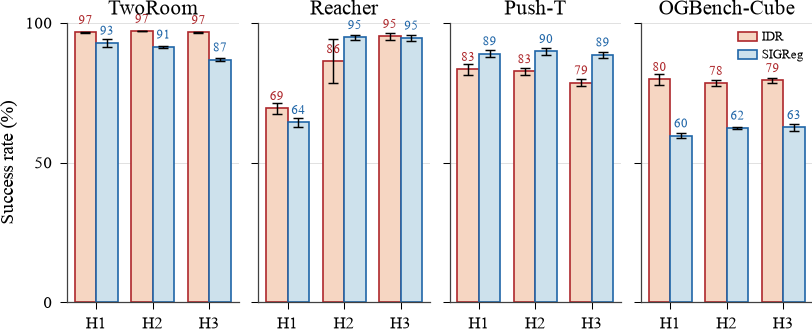

In [3]:
# Grouped bars: one panel per environment, x = history, two bars (IDR, SIGReg) per H.
COLORS = {"idr": {"fill": palette.get("Light Red", "#fcbba1"),
                  "edge": palette.get("Dark Red", "tab:red")},
          "sigreg": {"fill": palette.get("Light Blue", "#9ecae1"),
                     "edge": palette.get("Dark Blue", "tab:blue")}}


def lookup(env, method, h, field):
    row = summary[(summary.env_label == env) & (summary.method == method)
                  & (summary.history == h)]
    return float(row[field].iloc[0]) if len(row) else np.nan


fig, axes = plt.subplots(1, len(ENV_ORDER), figsize=(FULL_WIDTH, 2.3),
                         constrained_layout=True)
x = np.arange(len(HISTORIES))
w = 0.38
for ax, env in zip(axes, ENV_ORDER):
    for i, method in enumerate(["idr", "sigreg"]):
        means = [lookup(env, method, h, "mean") for h in HISTORIES]
        errs = [lookup(env, method, h, "sem") for h in HISTORIES]
        ax.bar(x + (i - 0.5) * w, means, w, yerr=errs,
               color=COLORS[method]["fill"], edgecolor=COLORS[method]["edge"],
               linewidth=0.8, capsize=2.5, label=METHOD_LABELS[method],
               error_kw={"elinewidth": 0.7, "capthick": 0.7})
        for xi, m in zip(x + (i - 0.5) * w, means):
            if np.isfinite(m):
                ax.text(xi, m + 2, f"{m:.0f}", ha="center", va="bottom",
                        fontsize=6, color=COLORS[method]["edge"])
    ax.set_title(env, pad=4)
    ax.set_xticks(x)
    ax.set_xticklabels([f"H{h}" for h in HISTORIES])
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 50, 100])
    ax.grid(axis="y", lw=0.45)
    ax.spines[["top", "right"]].set_visible(False)
    if ax is axes[0]:
        ax.set_ylabel("Success rate (%)")
    else:
        ax.set_yticklabels([])
axes[-1].legend(fontsize=6, loc="best")
plt.show()


In [4]:
# Final table: mean +/- SEM for every environment x method x history.
tbl = summary.copy()
tbl["success"] = tbl.apply(lambda r: f"{r['mean']:.1f} +/- {r['sem']:.1f}", axis=1)
pivot = (tbl.pivot_table(index=["env_label", "method"], columns="history",
                         values="success", aggfunc="first")
         .reindex(ENV_ORDER, level=0))
pivot.columns = [f"H={h}" for h in pivot.columns]
print("Planning success rate (%), mean +/- SEM over 5 seeds:")
display(pivot)

# Tidy CSV alongside the figure for the rebuttal.
tbl_out = tbl[["env_label", "method", "history", "mean", "sem", "n"]].sort_values(
    ["env_label", "method", "history"])
tbl_out.to_csv(EXP_DIR / "history_ablation_table.csv", index=False)
print(f"\nWrote {EXP_DIR / 'history_ablation_table.csv'}")
display(tbl_out)


Planning success rate (%), mean +/- SEM over 5 seeds:


H=1           H=2           H=3
env_label    method                                          
TwoRoom      idr     96.6 +/- 0.2  97.0 +/- 0.0  96.6 +/- 0.2
             sigreg  92.8 +/- 1.4  91.4 +/- 0.4  86.8 +/- 0.6
Reacher      idr     69.4 +/- 2.0  86.2 +/- 7.8  95.2 +/- 1.3
             sigreg  64.4 +/- 1.7  94.8 +/- 1.0  94.6 +/- 0.9
Push-T       idr     83.4 +/- 1.9  82.6 +/- 1.4  78.6 +/- 1.4
             sigreg  89.0 +/- 1.3  89.8 +/- 1.3  88.6 +/- 1.1
OGBench-Cube idr     79.8 +/- 1.9  78.4 +/- 1.0  79.4 +/- 1.0
             sigreg  59.6 +/- 0.9  62.4 +/- 0.4  62.6 +/- 1.3


Wrote /Users/pivashkov/Projects/sensorimotor-world-model/planning/experiments/history_ablation/history_ablation_table.csv


,env_label,method,history,mean,sem,n
0,OGBench-Cube,idr,1,79.8,1.881489,5
1,OGBench-Cube,idr,2,78.4,1.029563,5
2,OGBench-Cube,idr,3,79.4,1.029563,5
3,OGBench-Cube,sigreg,1,59.6,0.871780,5
4,OGBench-Cube,sigreg,2,62.4,0.400000,5
5,OGBench-Cube,sigreg,3,62.6,1.326650,5
6,Push-T,idr,1,83.4,1.913113,5
7,Push-T,idr,2,82.6,1.400000,5
8,Push-T,idr,3,78.6,1.363818,5
9,Push-T,sigreg,1,89.0,1.264911,5
